# ALNS hyperparameter analysis


## Imports

In [14]:
import sys
import os

root = os.path.dirname(os.getcwd())
sys.path.append(root)

import time
import numpy as np
import matplotlib.pyplot as plt

from cvrptw.parser import parse_solomon
from cvrptw.heuristics.alns import solve


## Configuration

Note: the best known minimises vehicles first and then distance while my solve function
minimises only distance so the gap can
be negative ie shorter distance but more vehicles which is why we also record
the vehicle count


In [15]:
INSTANCES = {
    'c101': '../data/solomon/c101.txt',
    'r101': '../data/solomon/r101.txt',
    'rc101': '../data/solomon/rc101.txt',
    'r201': '../data/solomon/r201.txt',
    'rc201': '../data/solomon/rc201.txt',
}
BEST_KNOWN = {
    'c101': 828.94,
    'r101': 1650.80,
    'rc101': 1696.95,
    'r201': 1252.37,
    'rc201': 1406.94,
}

SEEDS = [0, 1, 2]


## Run


In [16]:
def gap_to_ref(distance, ref):
    if ref is None:
        return float('nan')
    return (distance - ref) / ref * 100


def run(name, instance, seeds, **params):
    ref = BEST_KNOWN.get(name)
    records = []
    for seed in seeds:
        start = time.perf_counter()
        best, stopped_at = solve(instance, seed=seed, **params)
        total_time = time.perf_counter() - start
        distance = best.distance()
        records.append({
            'instance': name,
            'seed': seed,
            'distance': distance,
            'vehicles': len(best.routes),
            'gap': gap_to_ref(distance, ref),
            'runtime': total_time,
            'stopped_at': stopped_at,
            **params,
        })
    return records


## Parameter tunning

- Destruction size



In [17]:
DESTRUCTION_SIZES = [5, 10, 15, 20, 30, 40]
ITERATIONS = 300

n_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for destruction_size in DESTRUCTION_SIZES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, n=destruction_size)
        n_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} n={destruction_size} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 n=5 gap_mean=33.38043686575807%  dist_mean=1105.643793355015  time_mean=0.4528761333009849s  stop_mean=102.33333333333333
c101 n=10 gap_mean=16.90163776946015%  dist_mean=969.0444361261631  time_mean=2.5074905666600293s  stop_mean=115.0
c101 n=15 gap_mean=20.687534690171567%  dist_mean=1000.4272500607082  time_mean=3.8002907666377723s  stop_mean=93.66666666666667
c101 n=20 gap_mean=4.350385944485741%  dist_mean=865.0020892482202  time_mean=5.193267733324319s  stop_mean=94.66666666666667
c101 n=30 gap_mean=9.735686332625168%  dist_mean=909.6429982856631  time_mean=8.441742166605158s  stop_mean=73.0
c101 n=40 gap_mean=2.668865895212712%  dist_mean=851.0632969517764  time_mean=11.170469033299014s  stop_mean=61.333333333333336
r101 n=5 gap_mean=10.275803658947302%  dist_mean=1820.432966801902  time_mean=1.0105985666935642s  stop_mean=161.0
r101 n=10 gap_mean=7.51774317874914%  dist_mean=1774.902904394791  time_mean=1.6532502666814253s  stop_mean=129.66666666666666
r101 n=15 gap_mean=4

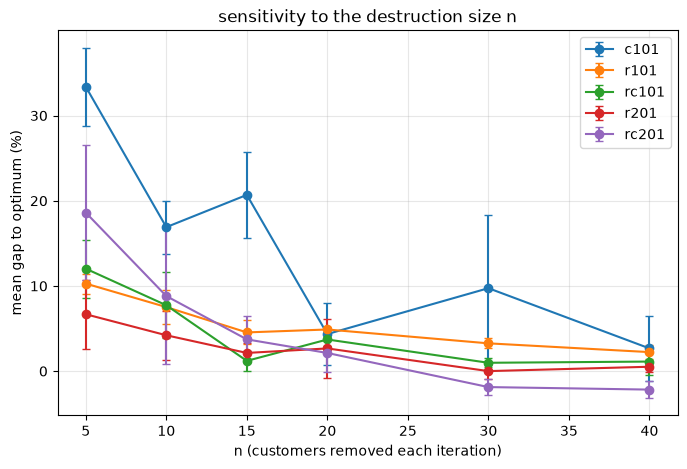

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in INSTANCES:
    means = np.array([np.nanmean([r['gap'] for r in n_list
                                  if r['instance'] == name and r['n'] == n_val])
                      for n_val in DESTRUCTION_SIZES])
    stds = np.array([np.nanstd([r['gap'] for r in n_list
                                if r['instance'] == name and r['n'] == n_val])
                     for n_val in DESTRUCTION_SIZES])
    ax.errorbar(DESTRUCTION_SIZES, means, yerr=stds, marker='o', capsize=3, label=name)

ax.set_xlabel('n (customers removed each iteration)')
ax.set_ylabel('mean gap to optimum (%)')
ax.set_title('sensitivity to the destruction size n')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## conclusiones para mi yo futuro (sucio asiq en español =) )

hay que subir el numero de iteraciones del early stopping ya que se esta trigreando casi siempre, lo puse bajo en un principio porque son problemas pequeños pero claramente tenia que ser msa alto (igual se puede poner en proporcion a el n total o algo del estilo)

hay que buscar el resto de hyperparametros uno a uno y buscar porque es tan lento (seguramente hay alguna funcion que limita mucho -> investigar)

parece que un n razonable es entre 20 y 30, pero de nuevo, sera en estos caoss que no hay tanta gente?, igual merece la pena ponerl oen funcion del numero de nodos -> investigar